In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
sales_df = pd.read_csv("train.csv")
games_df = pd.read_csv("vgsales.csv")

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
#the first 5 rows of the video game sales dataset
games_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
#shapes of both datasets
print("Superstore Sales Dataset Shape:", sales_df.shape)
print("Video Game Sales Dataset Shape:", games_df.shape)

Superstore Sales Dataset Shape: (9800, 18)
Video Game Sales Dataset Shape: (16598, 11)


In [5]:
#column names
print("Superstore Columns:")
print(sales_df.columns)

print("\nVideo Game Sales Columns:")
print(games_df.columns)

Superstore Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Video Game Sales Columns:
Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')


In [7]:
sales_df["Order Date"].head(10)

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: Order Date, dtype: str

In [8]:
# Convert date columns (day comes first)
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [9]:
# Extract time-based features
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["DayOfWeek"] = sales_df["Order Date"].dt.day_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [10]:
#assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

In [11]:
sales_df[[
    "Order Date",
    "Year",
    "Month",
    "Week",
    "DayOfWeek",
    "Quarter",
    "Season"
]].head(10)

,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn
5,2015-06-09,2015,6,24,Tuesday,2,Summer
6,2015-06-09,2015,6,24,Tuesday,2,Summer
7,2015-06-09,2015,6,24,Tuesday,2,Summer
8,2015-06-09,2015,6,24,Tuesday,2,Summer
9,2015-06-09,2015,6,24,Tuesday,2,Summer


In [12]:
print(sales_df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64


In [13]:
print("Duplicate Rows:", sales_df.duplicated().sum())

Duplicate Rows: 0


In [15]:
print(sales_df.dtypes)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                   str
Quarter                   int32
Season                      str
dtype: object


In [16]:
weekly_sales = sales_df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [18]:
monthly_sales = sales_df.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [19]:
category_sales = sales_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


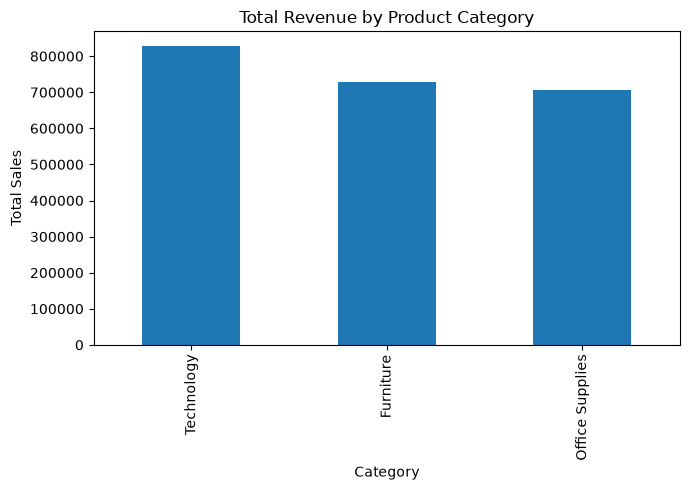

In [20]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/category_revenue.png")

plt.show()

In [21]:
region_yearly_sales = sales_df.groupby(["Year", "Region"])["Sales"].sum().unstack()

region_yearly_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


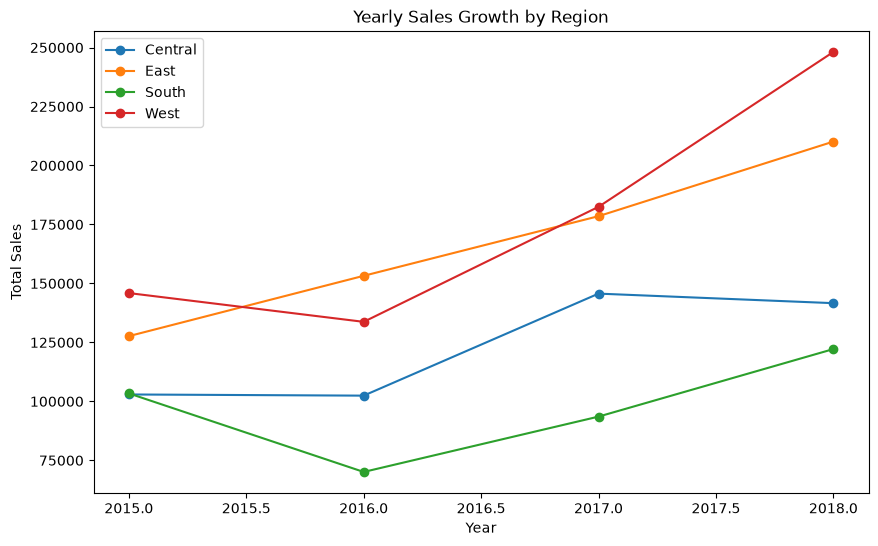

In [22]:
plt.figure(figsize=(10,6))

for region in region_yearly_sales.columns:
    plt.plot(
        region_yearly_sales.index,
        region_yearly_sales[region],
        marker="o",
        label=region
    )

plt.title("Yearly Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()

plt.savefig("charts/region_sales_growth.png")

plt.show()

### Observation

From the yearly sales trend, the **East** region shows the most consistent sales growth over the four-year period, with steady increases in revenue and fewer fluctuations compared to the other regions.

In [23]:
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

sales_df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [24]:
shipping_by_region = sales_df.groupby("Region")["Shipping Days"].mean()

print(shipping_by_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


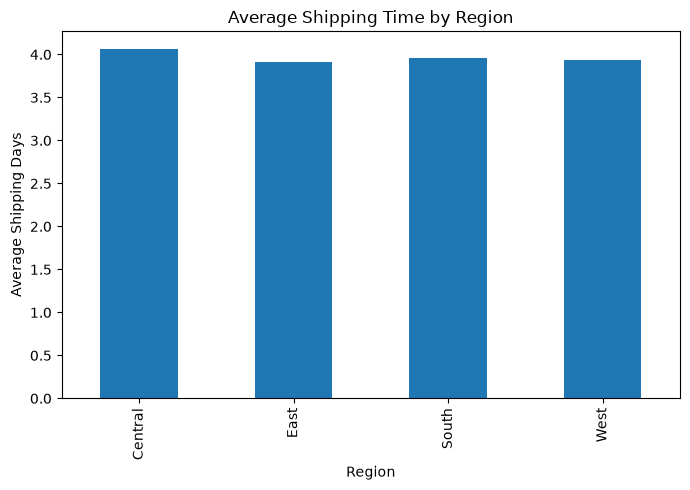

In [25]:
plt.figure(figsize=(7,5))

shipping_by_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.tight_layout()

plt.savefig("charts/shipping_time_by_region.png")

plt.show()

### Observation

The average shipping time is approximately **4 days** across all regions. The **Central** region has a slightly higher average shipping time, while the **East** region has the lowest. Overall, the differences are minimal, indicating that shipping performance is fairly consistent across all regions.

In [26]:
monthly_pattern = sales_df.groupby(["Year", "Month"])["Sales"].sum().unstack()

monthly_pattern

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,75249.3995,74543.6012
2017,18542.4910,22978.8150,51165.0590,38679.7670,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,43476.4740,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,83030.3888


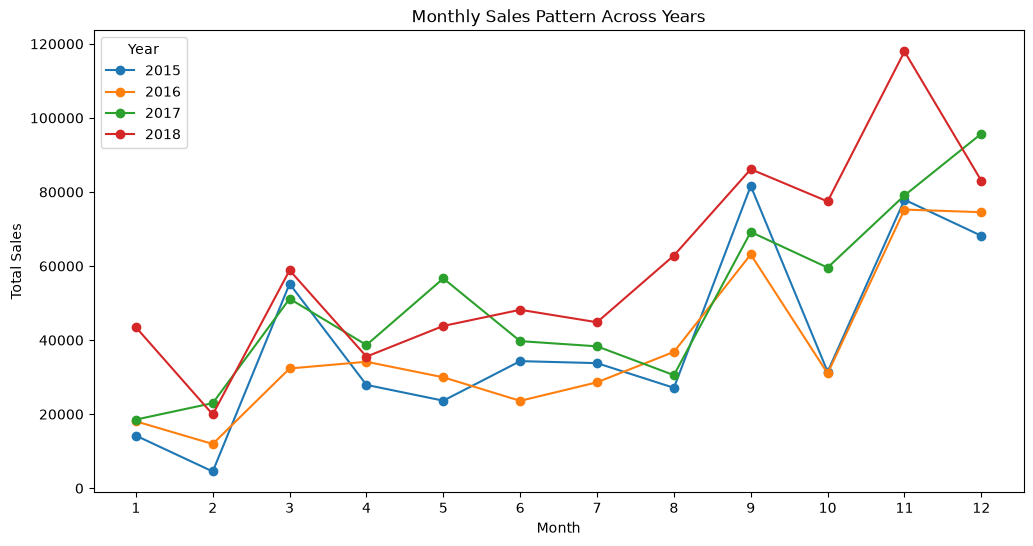

In [27]:
plt.figure(figsize=(12,6))

for year in monthly_pattern.index:
    plt.plot(
        monthly_pattern.columns,
        monthly_pattern.loc[year],
        marker="o",
        label=year
    )

plt.title("Monthly Sales Pattern Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.legend(title="Year")

plt.savefig("charts/monthly_seasonality.png")

plt.show()

### Observation

The monthly sales pattern shows clear seasonality across all four years. Sales generally increase during the last quarter of the year, with the highest sales occurring in **November** and **December**. These consistent spikes are likely due to holiday shopping, festive seasons, and year-end promotions, while the earlier months of the year show comparatively lower sales.

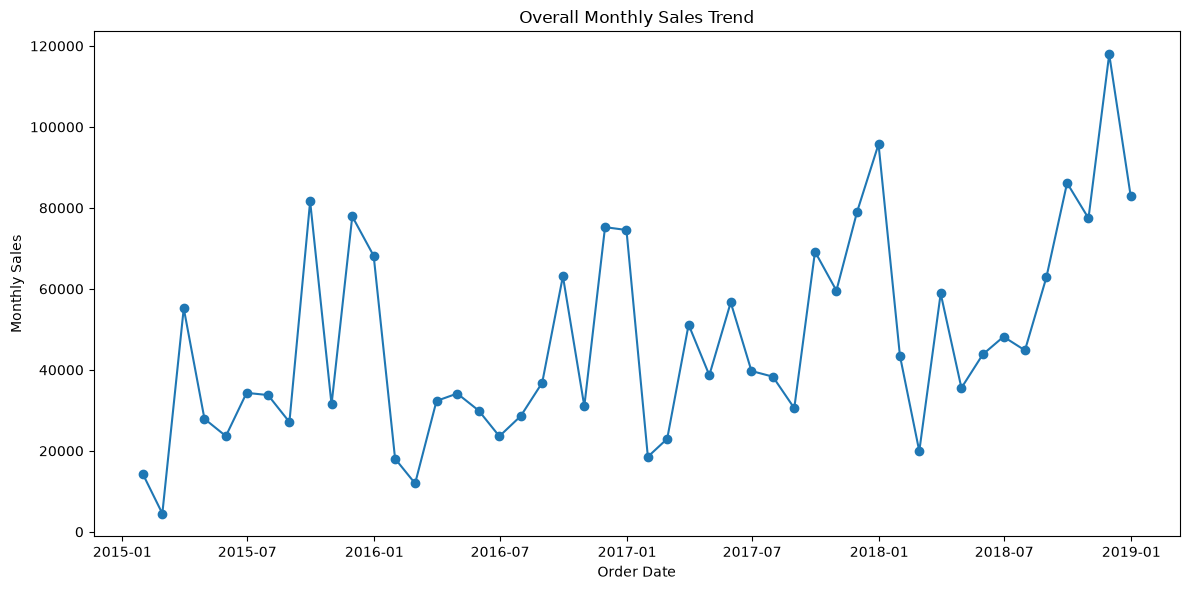

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.tight_layout()

plt.savefig("charts/overall_monthly_sales_trend.png")

plt.show()

In [32]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\sneha\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [34]:
monthly_sales_ts = monthly_sales.set_index("Order Date")

monthly_sales_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [35]:
decomposition = seasonal_decompose(
    monthly_sales_ts["Sales"],
    model="additive",
    period=12
)

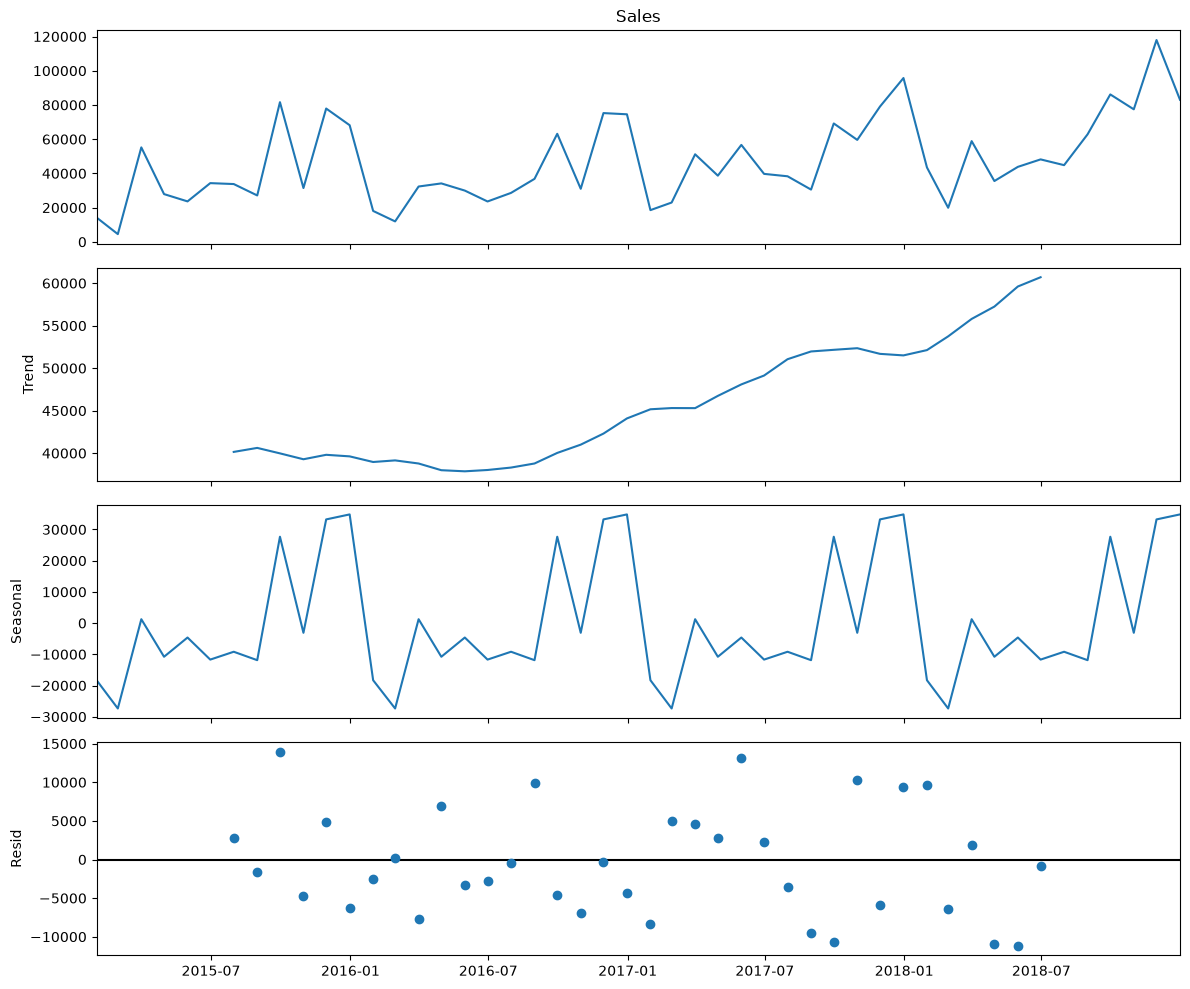

In [36]:
fig = decomposition.plot()
fig.set_size_inches(12, 10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png")

plt.show()

## Time Series Decomposition Observations

1. The trend component shows that overall sales increase over the four-year period, indicating positive business growth.

2. The seasonal component shows a repeating yearly pattern, confirming that sales are influenced by seasonal events such as holidays and festive shopping periods.

3. The residual component contains random fluctuations that are not explained by the trend or seasonality. These may be caused by promotions, special events, or unexpected market conditions.

4. The decomposition indicates that both long-term growth and seasonal demand play an important role in overall sales performance.

In [37]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(monthly_sales_ts["Sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## What is Stationarity?

A time series is called **stationary** when its statistical properties, such as the mean and variance, remain constant over time. Many forecasting models require stationary data because stable patterns make future predictions more reliable.

## ADF Test Interpretation

The Augmented Dickey-Fuller (ADF) test produced a p-value of **0.000278**, which is less than the significance level of **0.05**.

Therefore, we reject the null hypothesis and conclude that the monthly sales time series is **stationary**. Since the data is already stationary, differencing is **not required** before building forecasting models.

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [40]:
train = monthly_sales_ts.iloc[:-3]

test = monthly_sales_ts.iloc[-3:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

Training Data: (45, 1)
Testing Data: (3, 1)


In [41]:
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

print("SARIMA model trained successfully!")

C:\Users\sneha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\sneha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


SARIMA model trained successfully!


In [42]:
sarima_forecast = sarima_result.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean
confidence_intervals = sarima_forecast.conf_int()

print("Forecasted Sales:")
print(forecast_values)

Forecasted Sales:
2018-10-31    66177.602449
2018-11-30    92049.249675
2018-12-31    99965.168714
Freq: ME, Name: predicted_mean, dtype: float64


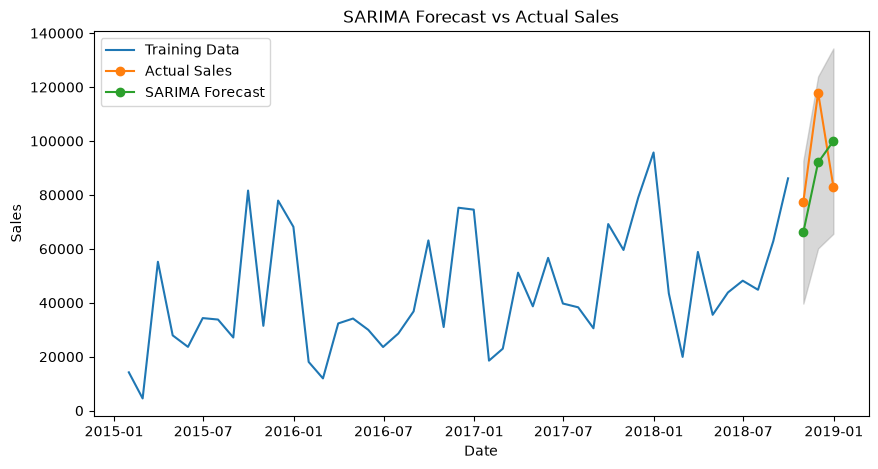

In [43]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train["Sales"], label="Training Data")

plt.plot(test.index, test["Sales"], label="Actual Sales", marker="o")

plt.plot(test.index, forecast_values, label="SARIMA Forecast", marker="o")

plt.fill_between(
    test.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color="gray",
    alpha=0.3
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.savefig("charts/sarima_forecast.png")

plt.show()

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

mae = mean_absolute_error(test["Sales"], forecast_values)

rmse = np.sqrt(mean_squared_error(test["Sales"], forecast_values))

mape = np.mean(
    np.abs((test["Sales"] - forecast_values) / test["Sales"])
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 18031.40466334434
RMSE: 19009.182061964573
MAPE: 18.966498056182964


In [45]:
%pip install prophet

  Using cached tqdm-4.68.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -------------- ------------------------- 4.5/12.1 MB 24.4 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.1 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 25.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 27.0 MB/s eta 0:00:00
Using cached tqdm-4.68.3-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\sneha\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [46]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [47]:
# Prepare data for Prophet
prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [48]:
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

print("Training Shape:", prophet_train.shape)
print("Testing Shape:", prophet_test.shape)

Training Shape: (45, 2)
Testing Shape: (3, 2)


In [49]:
prophet_model = Prophet()

prophet_model.fit(prophet_train)

print("Prophet model trained successfully!")

12:52:04 - cmdstanpy - INFO - Chain [1] start processing
12:52:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [50]:
future = prophet_model.make_future_dataframe(periods=3, freq="ME")

prophet_forecast = prophet_model.predict(future)

prophet_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,38802.832506,55282.228520
44,2018-09-30,86613.953316,78229.178215,94734.204460
45,2018-10-31,51318.943858,42683.067250,59255.299664
46,2018-11-30,90325.654784,82495.795496,98754.645562
47,2018-12-31,90041.084479,81916.808092,98065.605470


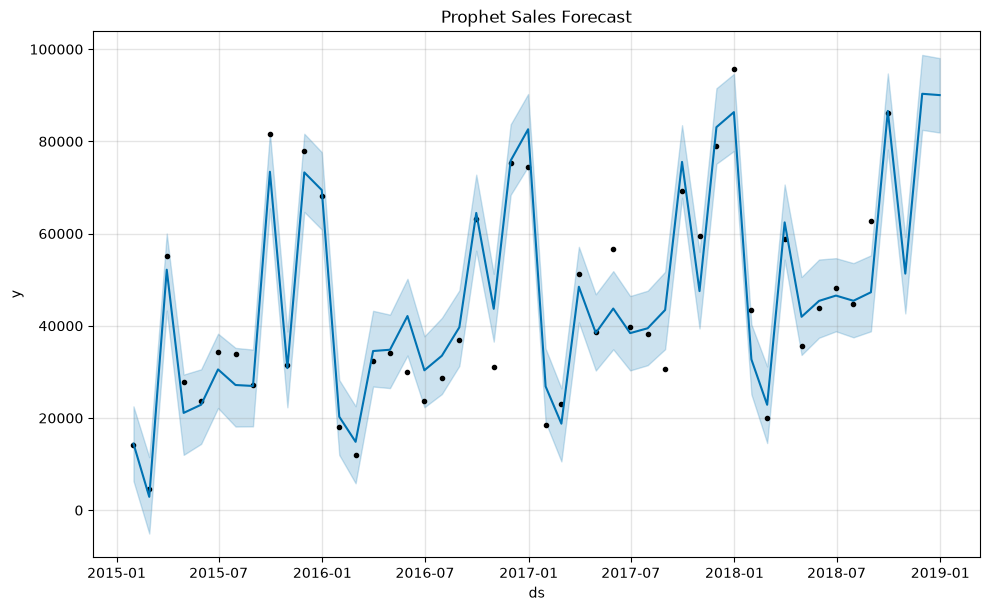

In [51]:
fig = prophet_model.plot(prophet_forecast)

plt.title("Prophet Sales Forecast")

plt.savefig("charts/prophet_forecast.png")

plt.show()

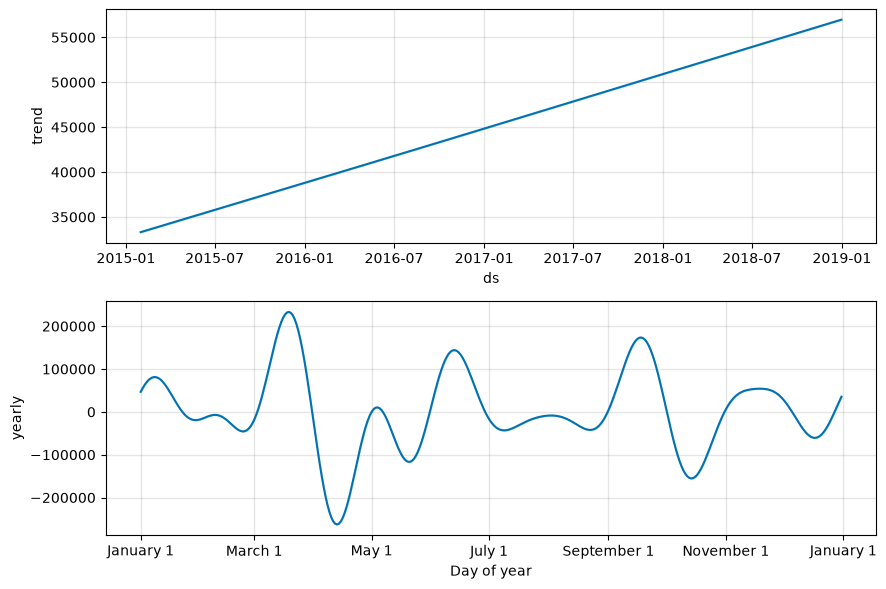

In [52]:
fig = prophet_model.plot_components(prophet_forecast)

plt.savefig("charts/prophet_components.png")

plt.show()

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

prophet_predictions = prophet_forecast.tail(3)["yhat"].values

actual_values = prophet_test["y"].values

mae_prophet = mean_absolute_error(actual_values, prophet_predictions)
rmse_prophet = np.sqrt(mean_squared_error(actual_values, prophet_predictions))
mape_prophet = np.mean(
    np.abs((actual_values - prophet_predictions) / actual_values)
) * 100

print("MAE:", mae_prophet)
print("RMSE:", rmse_prophet)
print("MAPE:", mape_prophet)

MAE: 20250.794412605523
RMSE: 22318.41133286054
MAPE: 21.86462827396082


In [54]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   --- ------------------------------------ 5.8/69.5 MB 27.0 MB/s eta 0:00:03
   ------ --------------------------------- 11.5/69.5 MB 27.7 MB/s eta 0:00:03
   ----------- ---------------------------- 19.1/69.5 MB 30.9 MB/s eta 0:00:02
   ---------------- ----------------------- 28.3/69.5 MB 33.8 MB/s eta 0:00:02
   ------------------ --------------------- 32.0/69.5 MB 31.2 MB/s eta 0:00:02
   -------------------- ------------------- 36.2/69.5 MB 29.1 MB/s eta 0:00:02
   ----------------------- ---------------- 40.6/69.5 MB 28.1 MB/s eta 0:00:02
   -------------------------- ------------- 46.4/69.5 MB 28.1 MB/s eta 0:00:01
   ----------------------------- ---------- 51.9/69.5 MB 27.5 MB/s eta 0:00:01
   -------------------------------- ------- 56.6/69.5 MB 27.3 MB/s eta 0:00:01
   ----------------------------------- ---- 62.1/69.5 MB 27.1 MB/s eta 0:00:01
   -------------------------------------- - 67.4/69.5 MB 27.0 


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\sneha\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [55]:
from xgboost import XGBRegressor

In [56]:
xgb_df = monthly_sales.copy()

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean3"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

def get_season(month):
    if month in [12,1,2]:
        return 1   # Winter
    elif month in [3,4,5]:
        return 2   # Spring
    elif month in [6,7,8]:
        return 3   # Summer
    else:
        return 4   # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [57]:
X = xgb_df[[
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean3",
    "Month",
    "Quarter",
    "Season"
]]

y = xgb_df["Sales"]

print(X.head())

         Lag1        Lag2       Lag3  RollingMean3  Month  Quarter  Season
3  55205.7970   4519.8920  14205.707  29210.848000      4        2       2
4  27906.8550  55205.7970   4519.892  35585.651667      5        2       2
5  23644.3030  27906.8550  55205.797  28624.697867      6        2       3
6  34322.9356  23644.3030  27906.855  30582.927200      7        3       3
7  33781.5430  34322.9356  23644.303  31740.671700      8        3       3


In [58]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (42, 7)
Testing Shape: (3, 7)


In [59]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [60]:
xgb_predictions = xgb_model.predict(X_test)

print("Predicted Sales:")
print(xgb_predictions)

Predicted Sales:
[86465.82 86506.77 84327.28]


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mape_xgb = np.mean(np.abs((y_test - xgb_predictions) / y_test)) * 100

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)

MAE: 13915.321041666664
RMSE: 18893.847269098238
MAPE: 13.285400568532047


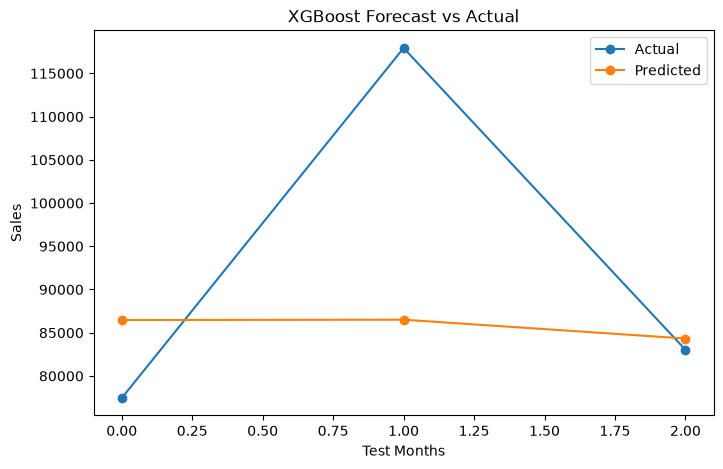

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    xgb_predictions,
    marker="o",
    label="Predicted"
)

plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Test Months")
plt.ylabel("Sales")

plt.legend()

plt.savefig("charts/xgboost_forecast.png")

plt.show()

In [64]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        mae,
        mae_prophet,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],
    "MAPE": [
        mape,
        mape_prophet,
        mape_xgb
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404663,19009.182062,18.966498
1,Prophet,20250.794413,22318.411333,21.864628
2,XGBoost,13915.321042,18893.847269,13.285401


In [67]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        mae,
        mae_prophet,
        mae_xgb
    ],

    "RMSE": [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE": [
        mape,
        mape_prophet,
        mape_xgb
    ],

    "Forecast Month 1": [
        forecast_values.iloc[0],
        prophet_predictions[0],
        xgb_predictions[0]
    ],

    "Forecast Month 2": [
        forecast_values.iloc[1],
        prophet_predictions[1],
        xgb_predictions[1]
    ],

    "Forecast Month 3": [
        forecast_values.iloc[2],
        prophet_predictions[2],
        xgb_predictions[2]
    ]
})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404663,19009.182062,18.966498,66177.602449,92049.249675,99965.168714
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479
2,XGBoost,13915.321042,18893.847269,13.285401,86465.820312,86506.773438,84327.281250


In [65]:
best_model = comparison.loc[comparison["RMSE"].idxmin()]

print("Best Forecasting Model:")
print(best_model)

Best Forecasting Model:
Model         XGBoost
MAE      13915.321042
RMSE     18893.847269
MAPE        13.285401
Name: 2, dtype: object


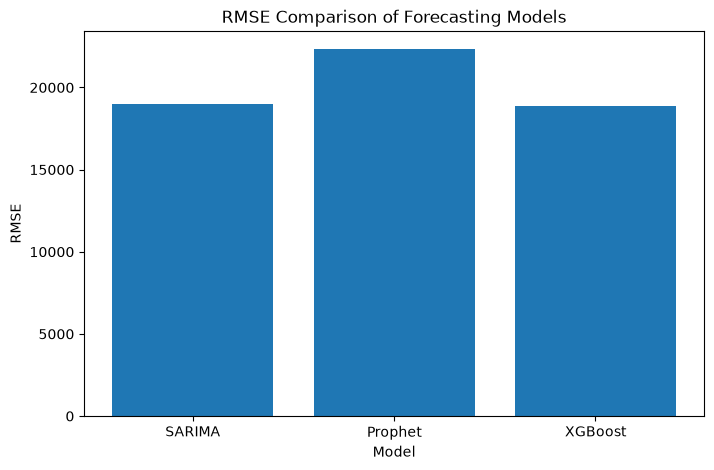

In [66]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("RMSE Comparison of Forecasting Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.savefig("charts/model_comparison.png")

plt.show()

## Forecasting Model Comparison

Among the three forecasting models, **XGBoost** achieved the lowest RMSE and provided the most accurate predictions for future monthly sales. Therefore, this model is recommended for future sales forecasting and business planning.

In [68]:
furniture_df = sales_df[sales_df["Category"] == "Furniture"]

technology_df = sales_df[sales_df["Category"] == "Technology"]

office_df = sales_df[sales_df["Category"] == "Office Supplies"]

west_df = sales_df[sales_df["Region"] == "West"]

east_df = sales_df[sales_df["Region"] == "East"]

print("Furniture:", furniture_df.shape)
print("Technology:", technology_df.shape)
print("Office Supplies:", office_df.shape)
print("West:", west_df.shape)
print("East:", east_df.shape)

Furniture: (2078, 25)
Technology: (1813, 25)
Office Supplies: (5909, 25)
West: (3140, 25)
East: (2785, 25)


In [69]:
def monthly_sales(df):
    return (
        df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
          .sum()
          .reset_index()
    )

furniture_monthly = monthly_sales(furniture_df)
technology_monthly = monthly_sales(technology_df)
office_monthly = monthly_sales(office_df)
west_monthly = monthly_sales(west_df)
east_monthly = monthly_sales(east_df)

print("Monthly datasets created successfully!")

Monthly datasets created successfully!


In [70]:
from xgboost import XGBRegressor

def forecast_xgb(monthly_df):

    df = monthly_df.copy()

    df["Lag1"] = df["Sales"].shift(1)
    df["Lag2"] = df["Sales"].shift(2)
    df["Lag3"] = df["Sales"].shift(3)
    df["RollingMean3"] = df["Sales"].rolling(3).mean()

    df["Month"] = df["Order Date"].dt.month
    df["Quarter"] = df["Order Date"].dt.quarter

    df = df.dropna()

    X = df[[
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter"
    ]]

    y = df["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    last = X.iloc[-1:]

    forecast = model.predict(last)

    return forecast[0]

In [71]:
furniture_forecast = forecast_xgb(furniture_monthly)
technology_forecast = forecast_xgb(technology_monthly)
office_forecast = forecast_xgb(office_monthly)
west_forecast = forecast_xgb(west_monthly)
east_forecast = forecast_xgb(east_monthly)

print("Furniture:", furniture_forecast)
print("Technology:", technology_forecast)
print("Office Supplies:", office_forecast)
print("West:", west_forecast)
print("East:", east_forecast)

Furniture: 31425.168
Technology: 21842.69
Office Supplies: 29633.475
West: 29698.771
East: 19774.78


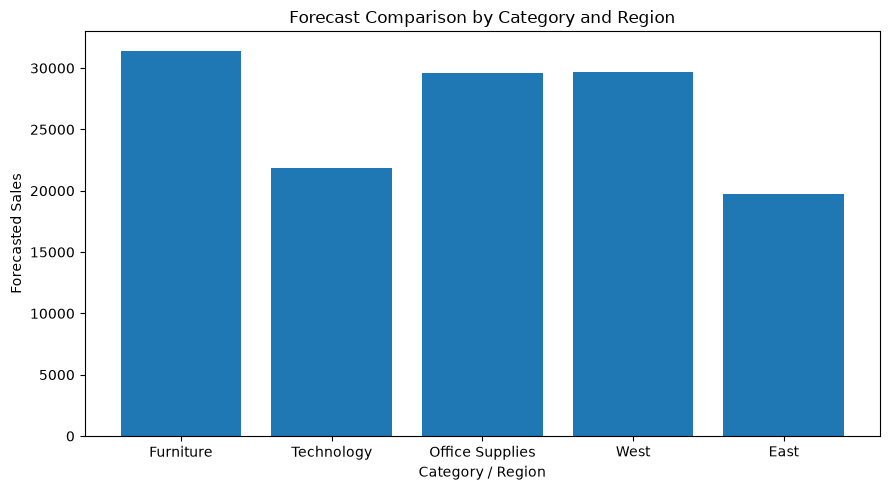

In [72]:
plt.figure(figsize=(9,5))

segments = [
    "Furniture",
    "Technology",
    "Office Supplies",
    "West",
    "East"
]

forecasts = [
    furniture_forecast,
    technology_forecast,
    office_forecast,
    west_forecast,
    east_forecast
]

plt.bar(segments, forecasts)

plt.title("Forecast Comparison by Category and Region")
plt.xlabel("Category / Region")
plt.ylabel("Forecasted Sales")

plt.tight_layout()

plt.savefig("charts/category_region_forecast.png")

plt.show()

## Task 4 Observation

Based on the XGBoost forecasts:

- **Furniture** has the highest projected sales (31,425), indicating the strongest upcoming demand among the product categories.
- **Office Supplies** is expected to remain stable with projected sales of approximately 29,633.
- **Technology** has a lower projected demand compared to Furniture and Office Supplies.
- Among the regions, the **West** region is expected to outperform the **East** region in upcoming sales.
- Therefore, inventory planning and marketing efforts should prioritize **Furniture products** and the **West region** to meet the anticipated demand.

## Strongest Upcoming Growth

According to the XGBoost forecasting model, the **Furniture** category is expected to show the strongest upcoming growth, with a forecasted sales value of approximately **31,425**. Among the regions, the **West** region is projected to perform better than the **East** region, with forecasted sales of approximately **29,699** compared to **19,775**. Therefore, the company should prioritize inventory planning and marketing efforts for the Furniture category and the West region to meet the expected increase in demand.

In [73]:
weekly_sales = (
    sales_df.groupby(pd.Grouper(key="Order Date", freq="W-SUN"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [74]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)

weekly_sales.head()

,Order Date,Sales,RollingMean,RollingStd
0,2015-01-04,304.508,NaN,NaN
1,2015-01-11,4619.108,NaN,NaN
2,2015-01-18,4130.533,NaN,NaN
3,2015-01-25,3092.544,3036.67325,1929.462566
4,2015-02-01,2527.914,3592.52475,953.362968


In [75]:
weekly_sales["ZScore"] = (
    (weekly_sales["Sales"] - weekly_sales["RollingMean"])
    / weekly_sales["RollingStd"]
)

weekly_sales.head()

,Order Date,Sales,RollingMean,RollingStd,ZScore
0,2015-01-04,304.508,NaN,NaN,NaN
1,2015-01-11,4619.108,NaN,NaN,NaN
2,2015-01-18,4130.533,NaN,NaN,NaN
3,2015-01-25,3092.544,3036.67325,1929.462566,0.028957
4,2015-02-01,2527.914,3592.52475,953.362968,-1.116690


In [76]:
zscore_anomalies = weekly_sales[
    weekly_sales["ZScore"].abs() > 2
]

print(zscore_anomalies)

Empty DataFrame
Columns: [Order Date, Sales, RollingMean, RollingStd, ZScore]
Index: []


In [77]:
zscore_anomalies = weekly_sales[
    weekly_sales["ZScore"].abs() > 1.5
]

print(zscore_anomalies)

Empty DataFrame
Columns: [Order Date, Sales, RollingMean, RollingStd, ZScore]
Index: []


In [78]:
weekly_sales["RollingMean"] = weekly_sales["Sales"].rolling(window=8).mean()
weekly_sales["RollingStd"] = weekly_sales["Sales"].rolling(window=8).std()

weekly_sales["ZScore"] = (
    (weekly_sales["Sales"] - weekly_sales["RollingMean"])
    / weekly_sales["RollingStd"]
)

zscore_anomalies = weekly_sales[
    weekly_sales["ZScore"].abs() > 2
]

print(zscore_anomalies)

    Order Date      Sales   RollingMean    RollingStd    ZScore
11  2015-03-22  37703.665   6832.006500  12546.138409  2.460650
29  2015-07-26  21590.080   8245.428325   6246.129535  2.136467
86  2016-08-28  15773.478   7515.302525   4020.682890  2.053924
89  2016-09-18  24095.960  10251.475400   6524.009519  2.122082
125 2017-05-28  23367.662  10265.959125   6524.022836  2.008225
168 2018-03-25  26029.904   8660.308925   7131.467537  2.435627


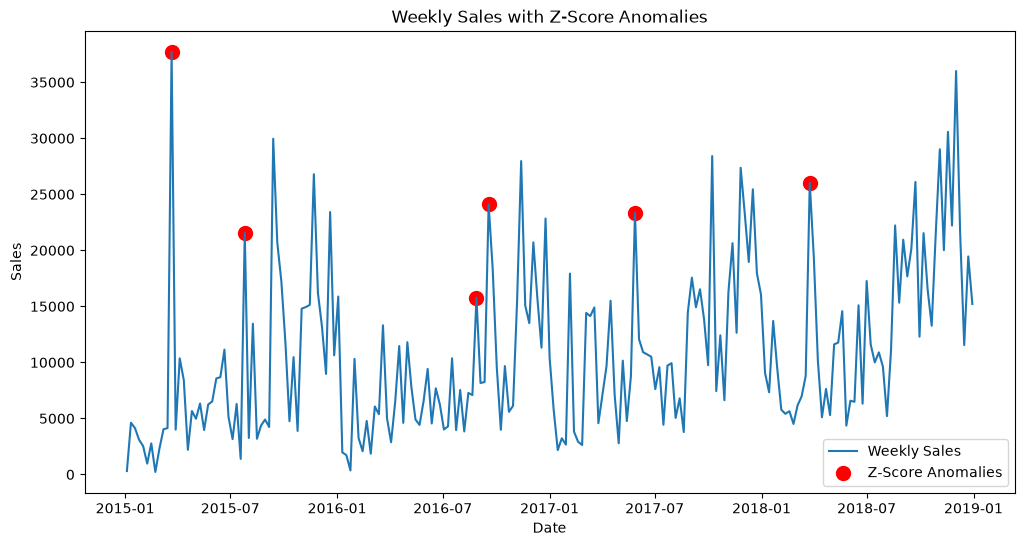

In [79]:
plt.figure(figsize=(12,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    zscore_anomalies["Order Date"],
    zscore_anomalies["Sales"],
    color="red",
    s=100,
    label="Z-Score Anomalies"
)

plt.title("Weekly Sales with Z-Score Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.savefig("charts/zscore_anomalies.png")

plt.show()

## Z-Score Anomaly Detection

The Z-Score method detected several weeks with unusually high sales compared to the surrounding weeks.

Possible business explanations include:

- Promotional campaigns or seasonal discounts.
- Holiday or festive shopping periods.
- New product launches or marketing events.
- Large bulk customer orders.
- Temporary spikes in customer demand.

## Isolation Forest vs Z-Score Comparison

Isolation Forest and Z-Score use different approaches to detect anomalies.

- **Isolation Forest** is a machine learning algorithm that identifies unusual observations based on how easily they can be isolated from the rest of the data.
- **Z-Score** is a statistical method that flags observations that deviate significantly from the rolling average.

The two methods identified similar periods of unusual sales but may not detect exactly the same weeks because they rely on different mathematical principles. Using both methods together provides a more reliable anomaly detection strategy.

In [80]:
sales_df["Year"] = sales_df["Order Date"].dt.year

total_sales = sales_df.groupby("Sub-Category")["Sales"].sum()

avg_order = sales_df.groupby("Sub-Category")["Sales"].mean()

monthly_sales_sub = (
    sales_df
    .groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

In [81]:
volatility = (
    monthly_sales_sub
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [82]:
yearly_sales = (
    sales_df
    .groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .unstack()
)

growth = (
    (yearly_sales.iloc[:, -1] - yearly_sales.iloc[:, 0])
    / yearly_sales.iloc[:, 0]
) * 100

growth = growth.fillna(0)

In [83]:
cluster_df = pd.DataFrame({
    "TotalSales": total_sales,
    "GrowthRate": growth,
    "Volatility": volatility,
    "AverageOrderValue": avg_order
})

cluster_df = cluster_df.fillna(0)

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

print("Data scaled successfully!")

Data scaled successfully!


In [85]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

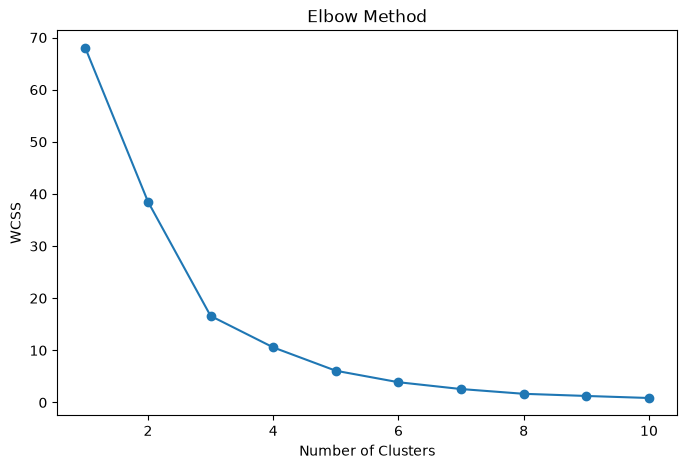

In [86]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.savefig("charts/elbow_method.png")

plt.show()

In [87]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_data)

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0
Appliances,104618.4030,165.242912,1821.621539,227.926804,2
Art,26705.4100,49.649531,330.488343,34.019631,2
Binders,200028.7850,65.778638,3848.223648,134.067550,0
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2


In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

cluster_df["PCA1"] = pca_data[:,0]
cluster_df["PCA2"] = pca_data[:,1]

cluster_df.head()

,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0,0.200367,0.116729
Appliances,104618.4030,165.242912,1821.621539,227.926804,2,-0.264248,0.707660
Art,26705.4100,49.649531,330.488343,34.019631,2,-1.676784,0.535820
Binders,200028.7850,65.778638,3848.223648,134.067550,0,0.484161,-0.805597
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2,-0.176589,0.003166


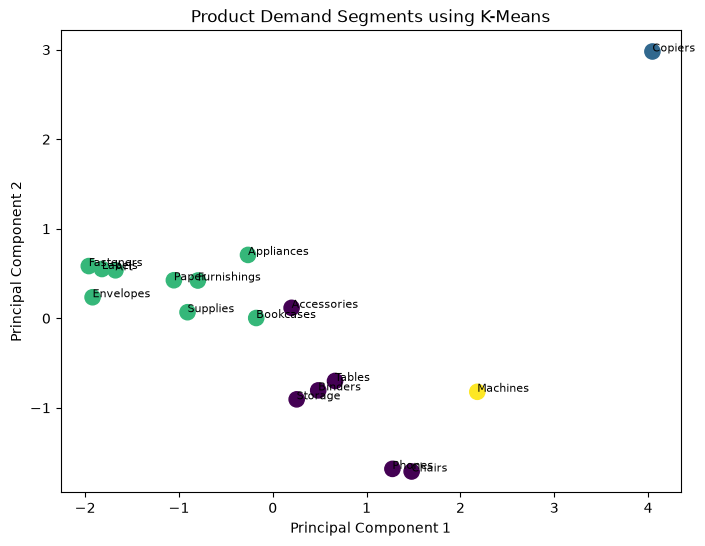

In [89]:
plt.figure(figsize=(8,6))

plt.scatter(
    cluster_df["PCA1"],
    cluster_df["PCA2"],
    c=cluster_df["Cluster"],
    s=120
)

for i in cluster_df.index:
    plt.text(
        cluster_df.loc[i,"PCA1"],
        cluster_df.loc[i,"PCA2"],
        i,
        fontsize=8
    )

plt.title("Product Demand Segments using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("charts/product_clusters.png")

plt.show()

In [90]:
for i in sorted(cluster_df["Cluster"].unique()):
    print("\nCluster", i)
    print(cluster_df[cluster_df["Cluster"] == i].index.tolist())


Cluster 0
['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']

Cluster 1
['Copiers']

Cluster 2
['Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper', 'Supplies']

Cluster 3
['Machines']


## Stocking Strategy Recommendations

### High Volume, Stable Demand
Maintain high inventory levels and replenish stock frequently to avoid shortages.

### High Value, Premium Products
Keep limited inventory while ensuring availability. Monitor demand carefully because these products have high selling prices.

### Low Volume, Moderate Demand
Maintain moderate inventory levels and review sales trends regularly before restocking.

### Specialized / High Investment Products
Keep minimal inventory and purchase based on customer demand or confirmed orders to reduce holding costs.

## Stocking Strategy Recommendations

### High Volume, Stable Demand
Maintain higher inventory levels and ensure regular stock replenishment to avoid stockouts.

### Growing Demand
Increase inventory gradually and invest in targeted marketing to support rising demand.

### Low Volume, High Volatility
Maintain limited stock levels and monitor demand closely to avoid overstocking.

### Declining Demand
Reduce inventory levels, limit new purchases, and consider promotional discounts to clear existing stock.